# 1 Выбор датасета и подготовка данных

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_moons
import math
import matplotlib.pyplot as plt

In [ ]:
X, Y = make_moons(n_samples = 600, noise = 0.2, random_state=42)

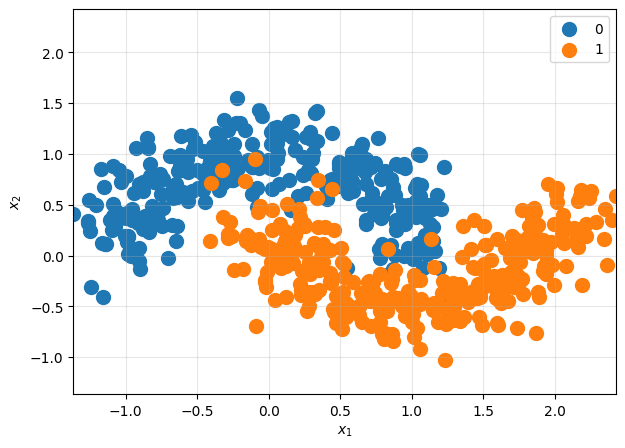

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X[Y == 0, 0],
    X[Y == 0, 1],
    s=100,
    label="0"
)

plt.scatter(
    X[Y == 1, 0],
    X[Y == 1, 1],
    s=100,
    label="1"
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(X.min(), X.max())
plt.ylim(X.min(), X.max())
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3)

In [ ]:
print(X_train[:5])
print(X_test[:5])
print(Y_train[:5])
print(Y_test[:5])

[[-0.54417269  1.18594999]
 [ 1.66827446 -0.4444165 ]
 [-0.02427266  0.06382021]
 [-0.12433247  0.10865448]
 [-0.64060178  0.29455102]]
[[ 0.32230633 -0.37971897]
 [-0.93760598  0.37611544]
 [ 0.74104859 -0.36286742]
 [ 1.48485206 -0.34256446]
 [ 0.42793147 -0.24626147]]
[0 1 1 1 0]
[1 0 1 1 1]


# 2 Реализация нейронной сети и исследование архитектур

In [ ]:
def tanh(x):
    return (math.exp(x) - math.exp(-x)) / (math.exp(x) + math.exp(-x))

def tanh_dif(x):
    return 1 - tanh(x) ** 2

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def sigmoid_dif(x):
    return sigmoid(x) * (1 - sigmoid(x))

def MSE(y_calc, y_real):
  total = 0
  for i in range(len(y_real)):
    total += (y_calc[i][0] - y_real[i]) ** 2
  return total / 2

def MSE_dif(y_calc, y_real):
  # sum = 0
  # for i in range(0, len(y_real)):
  #   sum += (y_calc[i] - y_real[i])
  # return [sum]
  return [y_calc[0] - y_real]

In [ ]:
class Neuron:
  def __init__(self, num, activation = "sigmoid"):
    self.activation = activation
    self.weights = np.random.randn(num)
    self.bias = 0
    self.input = []
    self.output = 0
    self.dL_dw = []
    self.dL_db = 0

  def forward(self, input):
    self.input = input

    self.output = 0
    for i in range(len(self.input)):
      self.output += self.weights[i] * self.input[i]
    self.output += self.bias
    self.z = self.output
    self.output = (sigmoid(self.output) if self.activation == 'sigmoid' else tanh(self.output))

    return self.output

  def backward(self, dL_da):
    mul = dL_da * (sigmoid_dif(self.z) if self.activation == 'sigmoid' else tanh_dif(self.z))
    dL_dx = [mul * i for i in self.weights]
    self.dL_dw = [mul * i for i in self.input]
    self.dL_db = mul
    return dL_dx

  def update(self, learning_rate):
    self.weights = [self.weights[i] - learning_rate * self.dL_dw[i] for i in range(len(self.weights))]
    self.bias = self.bias - learning_rate * self.dL_db


In [ ]:
class Layer:
  def __init__(self, input_size, output_size, activation = "sigmoid"):
    self.neurons = [Neuron(input_size, activation) for i in range(output_size)]
    self.input_size = input_size
    self.output_size = output_size
    self.outputs = []

  def forward(self, input):
    self.outputs = []
    for neuron in self.neurons:
      self.outputs.append(neuron.forward(input))
    return self.outputs

  def backward(self, dL_da):
    dL_dx = [0] * self.input_size
    for i in range(self.output_size):
      dL_dx_cur = self.neurons[i].backward(dL_da[i])
      dL_dx = [dL_dx[j] + dL_dx_cur[j] for j in range(self.input_size)]
    return dL_dx

  def update(self, learning_rate):
    for neuron in self.neurons:
      neuron.update(learning_rate)

In [ ]:
class Network:
  def __init__(self):
    self.layers = []
    self.loss = []

  def addLayer(self, layer):
    self.layers.append(layer)

  def forward(self, input):
    cur_input = input
    for layer in self.layers:
      cur_input = layer.forward(cur_input)
    return cur_input

  def backward(self, output):
    dL_da = MSE_dif(self.layers[-1].outputs, output)
    for i in range(len(self.layers) - 1, -1, -1):
      dL_da = self.layers[i].backward(dL_da)

  def predict(self, input):
    return self.forward(input)

  def update(self, learning_rate):
    for layer in self.layers:
      layer.update(learning_rate)

  def train(self, x_train, y_train, epoch = 100, learning_rate = 0.001):
    print('============================')
    for i in range(epoch):
      for x, y in zip(x_train, y_train):
        self.forward(x)
        self.backward(y)
        self.update(learning_rate)

      prediction = [self.forward(x_train[i]) for i in range(len(x_train))]
      loss = MSE([prediction[i] for i in range(len(prediction))], [y_train[i] for i in range(len(y_train))])
      self.loss.append(loss)
      if i % (epoch // 10) == 0:
        print(f"Epoch {i + 1}:")
        print(f"Loss: {loss}")
    print(f"Epoch {epoch}:")
    print(f"Loss: {loss}")
    print('============================')

  def get_loss(self):
    return self.loss

In [ ]:
models_layers = [[2, 1],
                 [2, 2, 1],
                 [2, 8, 1],
                 [2, 8, 8, 1]]

models = []
for m in models_layers:
  np.random.seed(42)
  network = Network()
  for i in range(1, len(m)):
    if i + 1 == len(m):
      network.addLayer(Layer(m[i - 1], m[i], 'sigmoid'))
    else:
      network.addLayer(Layer(m[i - 1], m[i], 'tanh'))
  models.append(network)

Модель со слоями [2, 1]
Epoch 1:
Loss: 36.72777492371122
Epoch 501:
Loss: 19.337492279371837
Epoch 1001:
Loss: 19.33068935471812
Epoch 1501:
Loss: 19.330536366896315
Epoch 2001:
Loss: 19.330534450247743
Epoch 2501:
Loss: 19.33053486644706
Epoch 3001:
Loss: 19.330534963717017
Epoch 3501:
Loss: 19.330534981687375
Epoch 4001:
Loss: 19.33053498489421
Epoch 4501:
Loss: 19.33053498546308
Epoch 5000:
Loss: 19.33053498556381
Модель со слоями [2, 2, 1]
Epoch 1:
Loss: 50.97218543663959
Epoch 501:
Loss: 18.7939543440471
Epoch 1001:
Loss: 18.392921449335397
Epoch 1501:
Loss: 17.926803019428064
Epoch 2001:
Loss: 17.503813903712395
Epoch 2501:
Loss: 17.20009985761669
Epoch 3001:
Loss: 17.021862947939372
Epoch 3501:
Loss: 16.89718147303059
Epoch 4001:
Loss: 16.75252089050582
Epoch 4501:
Loss: 16.589385627216448
Epoch 5000:
Loss: 16.477078126493904
Модель со слоями [2, 8, 1]
Epoch 1:
Loss: 44.26363976239433
Epoch 501:
Loss: 6.944971474225928
Epoch 1001:
Loss: 6.331596515801089
Epoch 1501:
Loss: 6.1452

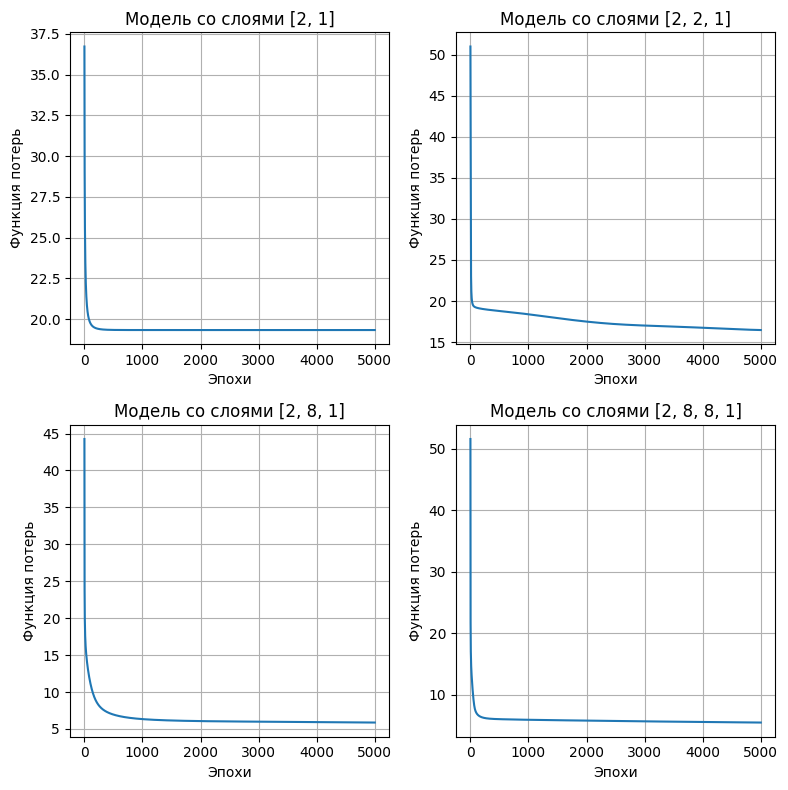

In [ ]:
epoch = 5000
learning_rate = 0.01

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,8))
axes = ax.flatten()

for i in range(4):
  print(f"Модель со слоями {models_layers[i]}")
  models[i].train(X_train, Y_train, epoch = epoch, learning_rate = learning_rate)
  train_loss = models[i].get_loss()
  axes[i].plot([_+1 for _ in range(epoch)], train_loss)
  axes[i].set_xlabel("Эпохи")
  axes[i].set_ylabel("Функция потерь")
  axes[i].grid(True)
  axes[i].set_title(f"Модель со слоями {models_layers[i]}")

fig.tight_layout()
fig.show()

In [ ]:
def evaluate(y_pred, y_real):
  y_pred = [1 if _[0] >= 0.5 else 0 for _ in y_pred]
  y_right = 0
  for i in range(len(y_real)):
    y_right += (1 if y_real[i] == y_pred[i] else 0)
  return y_right / len(y_real)

In [ ]:
for i in range(4):
  print('============================')
  print(f"Модель со слоями {models_layers[i]}")
  print(f"На тренировочных данных: {evaluate([models[i].predict(X_train[j]) for j in range(len(X_train))], Y_train)}")
  print(f"На тестовых данных: {evaluate([models[i].predict(X_test[j]) for j in range(len(X_test))], Y_test)}")
  print('============================')

Модель со слоями [2, 1]
На тренировочных данных: 0.8785714285714286
На тестовых данных: 0.8666666666666667
Модель со слоями [2, 2, 1]
На тренировочных данных: 0.8690476190476191
На тестовых данных: 0.8833333333333333
Модель со слоями [2, 8, 1]
На тренировочных данных: 0.969047619047619
На тестовых данных: 0.9722222222222222
Модель со слоями [2, 8, 8, 1]
На тренировочных данных: 0.9714285714285714
На тестовых данных: 0.9611111111111111


In [ ]:
x_min = X.min()
x_max = X.max()
pad = (x_max - x_min) * 0.1
xx, yy = np.meshgrid(np.linspace(x_min - pad, x_max + pad, 100), np.linspace(x_min - pad, x_max + pad, 100))

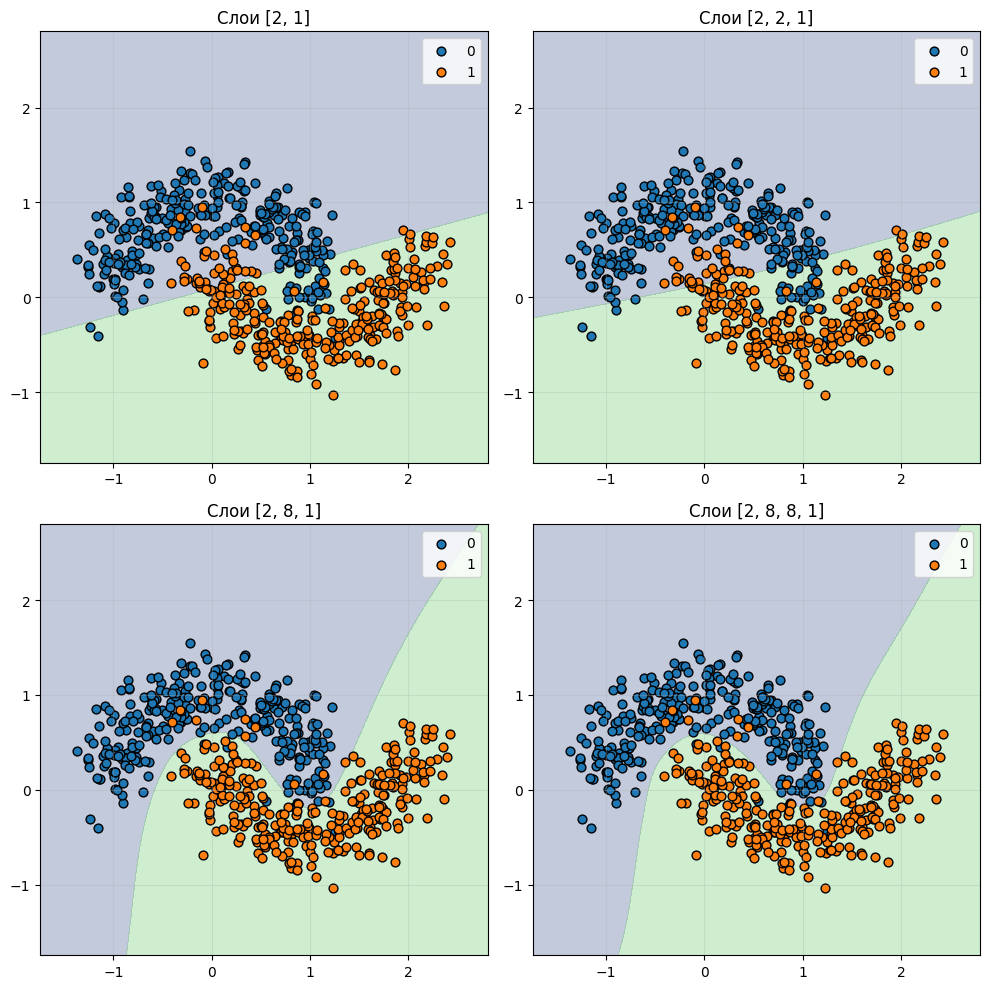

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
axes = ax.flatten()

grid = np.c_[xx.ravel(), yy.ravel()]

for i in range(4):
    pred = [models[i].predict(p)[0] for p in grid]
    Z = np.array(pred).reshape(xx.shape)
    axes[i].contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3)
    axes[i].scatter(X[Y == 0, 0], X[Y == 0, 1], s=40, label="0", edgecolor="k")
    axes[i].scatter(X[Y == 1, 0], X[Y == 1, 1], s=40, label="1", edgecolor="k")
    axes[i].set_title(f"Слои {models_layers[i]}")
    axes[i].set_xlim(xx.min(), xx.max())
    axes[i].set_ylim(yy.min(), yy.max())
    axes[i].grid(alpha=0.3)
    axes[i].legend()

fig.tight_layout()
fig.show()



# 3 Исследование скорости обучения

Лучшая модель со слоями [2, 8, 1]. Её точность сравнима с точностью модели [2, 8, 8, 1], но эта можель имеет большее число слоёв, нейронов и связей, она будет быстрее медленее и более склона к переобучению.

Epoch 1:
Loss: 89.35164168712267
Epoch 501:
Loss: 13.81128884478317
Epoch 1001:
Loss: 11.426594511391633
Epoch 1501:
Loss: 9.932719445327526
Epoch 2001:
Loss: 8.926137861160994
Epoch 2501:
Loss: 8.256640771509135
Epoch 3001:
Loss: 7.8110138129608915
Epoch 3501:
Loss: 7.503338615737672
Epoch 4001:
Loss: 7.280185650762578
Epoch 4501:
Loss: 7.110405911027094
Epoch 1:
Loss: 45.4825683040538
Epoch 501:
Loss: 6.972533740210143
Epoch 1001:
Loss: 6.315900990257386
Epoch 1501:
Loss: 6.028833928388785
Epoch 2001:
Loss: 5.882459572203839
Epoch 2501:
Loss: 5.796054287596567
Epoch 3001:
Loss: 5.733885236284325
Epoch 3501:
Loss: 5.681371551708615
Epoch 4001:
Loss: 5.6330296510791635
Epoch 4501:
Loss: 5.588654919252688
Epoch 1:
Loss: 20.262128496898136
Epoch 501:
Loss: 5.559735509155009
Epoch 1001:
Loss: 5.340808527099313
Epoch 1501:
Loss: 5.245382592086682
Epoch 2001:
Loss: 5.1357314216545324
Epoch 2501:
Loss: 5.081785388724938
Epoch 3001:
Loss: 5.045892861835918
Epoch 3501:
Loss: 5.01226022432539
E

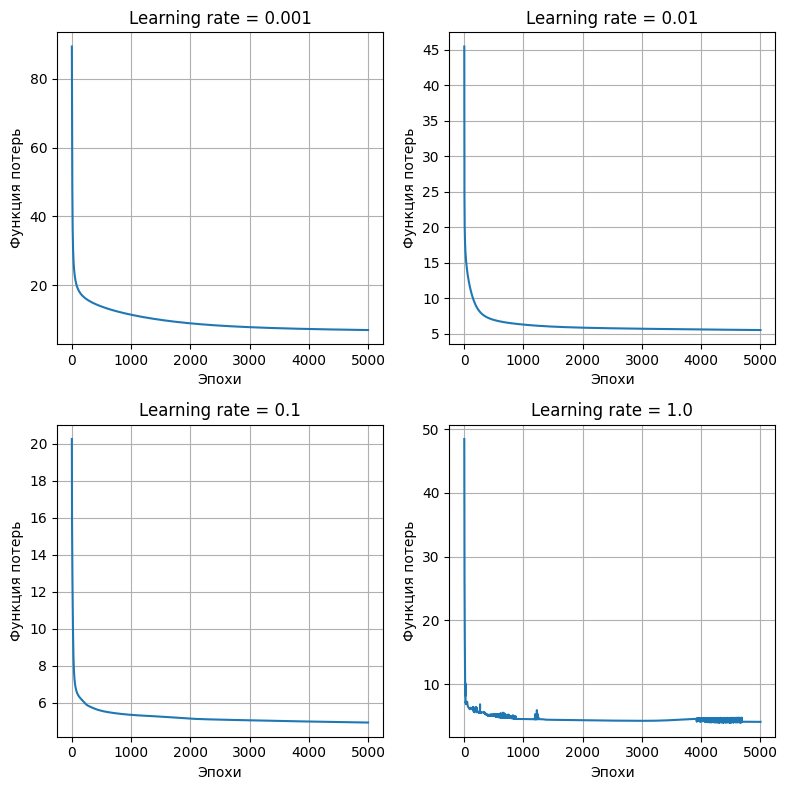

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,8))
axes = ax.flatten()

for learning_rate_r, i in zip([0.001, 0.01, 0.1, 1.0], [0, 1, 2, 3]):
  np.random.seed(42)
  model = Network()
  model.addLayer(Layer(2, 8, 'tanh'))
  model.addLayer(Layer(8, 1, 'sigmoid'))
  model.train(X_train, Y_train, epoch = 5000, learning_rate=learning_rate_r)

  train_loss = model.get_loss()
  axes[i].plot([_+1 for _ in range(5000)], train_loss)
  axes[i].set_xlabel("Эпохи")
  axes[i].set_ylabel("Функция потерь")
  axes[i].grid(True)
  axes[i].set_title(f"Learning rate = {learning_rate_r}")

fig.tight_layout()
fig.show()

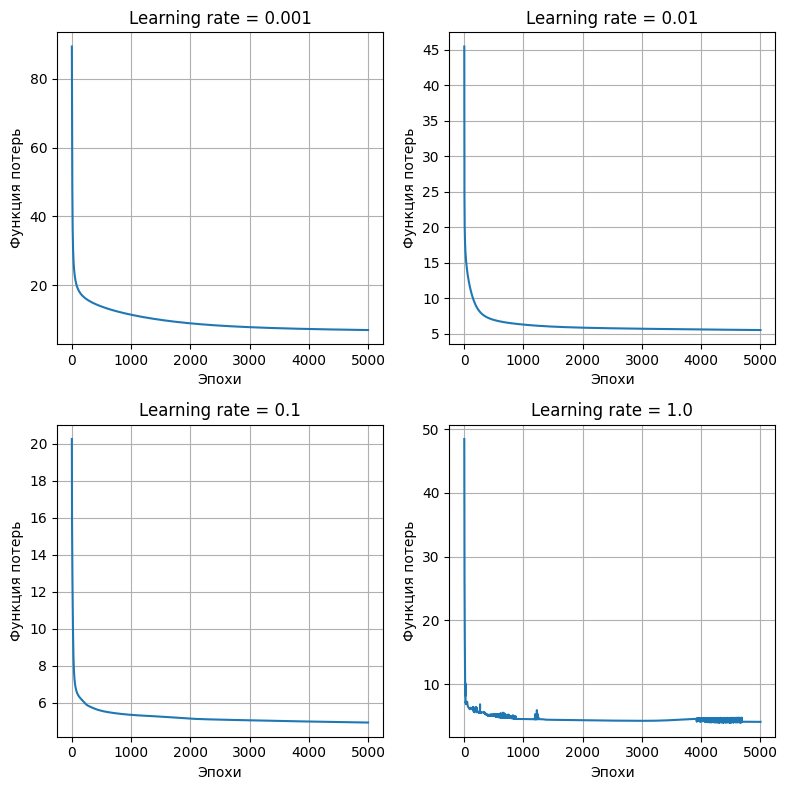

**Скорость сходимости и устойчивость обучения.**

| r | Эпоха с Loss < 5 | Loss на эпохе 500 | Loss на эпохе 1000 | Loss на эпохе 2000 | Loss на эпохе 5000 |
| :--- | :---: | :---: | :---: | :---: | ---: |
| 0.001 | - | ~13.8 | ~11.4 | ~8.9 | ~7.07 |
| 0.01 | - | ~6.97 | ~6.3 | ~5.88 | ~5.54 |
| 0.1 | ~3500 | ~5.56 | ~5.3 | ~5.1 | ~4.93 |
| 1.0 | ~500 | ~5.05 | ~4.5 | ~4.3 | ~4.39 |

При увеличении learning rate скорость выхода на плато возрастает: r=0.1 и r=1.0 достигают плато за первые ~500 эпох, r=0.01 — примерно к 1500-й, а r=0.001 подходит к нему лишь к концу 5000 эпох. Однако, при learning_rate=1.0 можно заметить, что функция потерь теряет монотонность, ее значения (а значит и график) начинают с определённого момента иногда колебаться, из-за чего график получается не гладким, а со скачками.

# 4 Анализ результатов

<h2> Линейная модель (без скрытых слоёв) не справляется с линейно неразделимыми данными

1. Из графика с решающей границей мы видим, что набор данных не линейный и его невозможно разделить на две группы одной прямой линий;
2. В сравнении точности линейной модели с другими видно, что она уступает другим и и на 10 п.п. на тестовой выборке.

<h2> Увеличение числа нейронов и слоёв повышает выразительную способность сети

С увеличением нейронов слоёв мы видим:
1. На графиках решающих границ, эти границы уже не просто прямые, но кривые, которые лучше разделяю области данных на группы;
2. Точности моделей [2, 8, 1] и [2, 8, 8, 1] лучше моделей [2, 1] и [2, 2, 1].

<h2> Почему для данной задачи необходима нелинейная функция активации

При обучении моделей используется алгоритм обратного распространения и идея градиентного спуска. Градиент — это вектор частных производных, следовательно, для его вычисления необходима дифференцируемость. При этом функция должна также иммитировать ступенчатую функцию (функция Хевисайда не является дифференцируемой).

<h2> Вывод о влиянии скорости обучения на сходимость градиентного спуска.

Малые r дают стабильное, но медленное обучение; большие — быстрое, но менее устойчивое.